In [1]:
from BLEanalysis.signals import Signals

In [6]:
!ls "/home/mike/Documents/Research/bluetooth_experiments/March 26 2025 Field Trial/Range Trials/"

1l.log	3l.log	5l.log	7l.log	9l.log	      IMG_3531.jpg  IMG_3535.jpg
1.log	3.log	5.log	7.log	9.log	      IMG_3532.jpg  IMG_3536.jpg
2l.log	4l.log	6l.log	8l.log	IMG_3529.jpg  IMG_3533.jpg  IMG_3537.jpg
2.log	4.log	6.log	8.log	IMG_3530.jpg  IMG_3534.jpg


In [7]:
testsigs = Signals("/home/mike/Documents/Research/bluetooth_experiments/March 26 2025 Field Trial/Range Trials/1.log",['c',],angleOffset=0)

Standardising angles and times (shifting by 0.00 degrees)


In [33]:
d = testsigs.data[200:,:] #RSSI, ID, Angle, Time

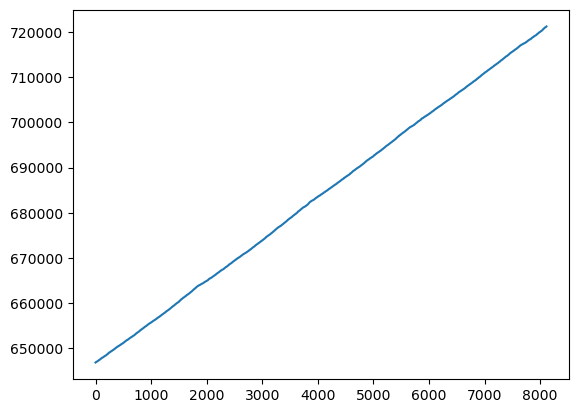

In [34]:
plt.plot(d[:,-1])

In [66]:
import matplotlib.pyplot as plt
import numpy as np
theta = 0.5
index_of_packet = np.argmin((np.abs(d[(d[:,-1]<d[0,-1]+201),2]-theta)))

rssis = []
while True:
    searchtimestart = d[index_of_packet,3]+1750
    searchtimeend = d[index_of_packet,3]+2250
    timeindexstart,timeindexend = np.argmin(np.abs(d[:,3]-searchtimestart)),np.argmin(np.abs(d[:,3]-searchtimeend))
    print(index_of_packet)
    index_of_packet = np.argmin(np.abs(d[timeindexstart:timeindexend,2]-theta))+timeindexstart
    error = np.abs(d[index_of_packet,2]-theta)
    if error>0.1:
        print("Not found :(")
        rssi.append(np.nan)
    else:
        print("RSSI=%0.2f, ID=%0.1f, Angle=%0.2f, Time=%0.2f" % tuple(d[index_of_packet,:]))
        rssis.append(d[index_of_packet,0])

6
RSSI=-78.00, ID=99.0, Angle=0.51, Time=648754.00
226
RSSI=-72.00, ID=99.0, Angle=0.49, Time=650626.00
433
RSSI=-78.00, ID=99.0, Angle=0.51, Time=652519.00
654
RSSI=-74.00, ID=99.0, Angle=0.49, Time=654386.00
853
RSSI=-81.00, ID=99.0, Angle=0.51, Time=656278.00
1069
RSSI=-76.00, ID=99.0, Angle=0.52, Time=658154.00
1277
RSSI=-92.00, ID=99.0, Angle=0.51, Time=660036.00
1472
RSSI=-74.00, ID=99.0, Angle=0.47, Time=661902.00
1660
RSSI=-80.00, ID=99.0, Angle=0.49, Time=663787.00
1844
RSSI=-85.00, ID=99.0, Angle=0.51, Time=665663.00
2092
RSSI=-81.00, ID=99.0, Angle=0.51, Time=667547.00
2305
RSSI=-81.00, ID=99.0, Angle=0.52, Time=669432.00
2506
RSSI=-81.00, ID=99.0, Angle=0.49, Time=671293.00
2724
RSSI=-75.00, ID=99.0, Angle=0.45, Time=673165.00
2923
RSSI=-92.00, ID=99.0, Angle=0.51, Time=675062.00
3122
RSSI=-85.00, ID=99.0, Angle=0.51, Time=676942.00
3311
RSSI=-78.00, ID=99.0, Angle=0.52, Time=678817.00
3503
RSSI=-75.00, ID=99.0, Angle=0.49, Time=680684.00
3689
RSSI=-82.00, ID=99.0, Angle=0.

ValueError: attempt to get argmin of an empty sequence

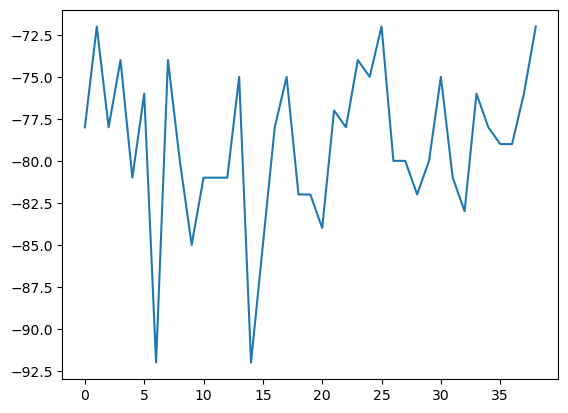

In [67]:
plt.plot(rssis)